# Tutorial: Support Vector Machines (SVM) for Classification

A **Support Vector Machine (SVM)** is a supervised machine learning algorithm used for classification (and regression). For classification, its goal is to find the decision boundary that best separates classes.

SVMs are especially effective when:

- You have a moderate-sized dataset.
- The number of features is large.
- Classes can be separated with a clear margin.
- You need flexible nonlinear boundaries through kernels.

We'll use **scikit-learn**, Python's most popular machine learning library.

---

## 1. Install Dependencies in the $\texttt{uitai}$ environment

```bash
pip install seaborn
```

---


## 2. The Core Idea of an SVM

For a binary classification problem, an SVM tries to find a hyperplane:

$$ w^T x + b = 0$$


that separates the two classes with the <font color='green'>**largest possible margin** </font>.

The points closest to the boundary are called <font color='green'>**support vectors**</font>. These are especially important because they determine where the classifier places the decision boundary.

### Soft margin and `C`

Real-world data is rarely perfectly separable. SVM uses the parameter `C` to balance:

- A **large `C`**: tries harder to classify every training example correctly; may overfit.
- A **small `C`**: allows some errors in exchange for a wider margin; may generalize better.


---

## 3. Load a Classification Dataset

Let's use the built-in breast cancer dataset. It is a binary classification dataset: malignant vs. benign tumors.


In [2]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print(X.head())
print(y.value_counts())
print(data.target_names)



   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           


---

## 4. Split into training and test data



In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


---

## 5. Scale Features

Feature scaling is very important for SVMs.

SVMs depend on distances between observations. If one feature ranges from 0–100,000 and another from 0–1, the larger-scale feature can dominate the model.

Use `StandardScaler`:

$$ z = \frac{x - \mu}{\sigma} $$


where $\mu$ is the mean and $\sigma$ is the standard deviation.

The safest approach is to use a `Pipeline`, which ensures scaling is fit only on training data.


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

svm_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['mean radius','mean texture','mean perimeter',...,'worst concave points', 'worst symmetry','worst fractal dimension']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True



---

## 6. Make Predictions


In [8]:
y_pred = svm_model.predict(X_test)

print(y_pred[:10])

[0 1 0 1 0 1 1 0 0 0]



---

## 7. Evaluate the Classifier


In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

Accuracy: 0.982

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114




---

### 7.1 Interpretation

A classification report includes:

- <font color='green'>**Precision**</font>: Of the samples predicted as a class, how many were correct?
- <font color='green'>**Recall**</font>: Of the true samples in a class, how many did the model find?
- <font color='green'>**F1-score**</font>: Harmonic mean of precision and recall.
- <font color='green'>**Support**</font>: Number of true examples for each class.

For medical classification, recall can be especially important. Missing a malignant case could be costly.



---

## 8. Visualize the Confusion Matrix


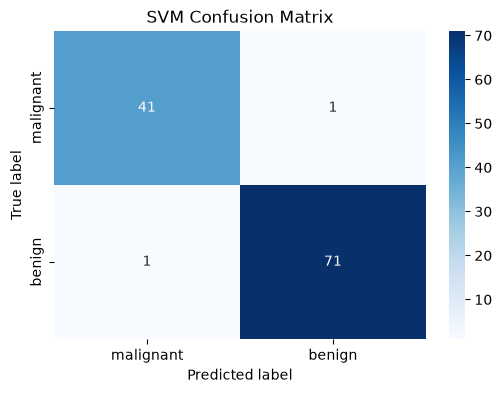

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=data.target_names,
    yticklabels=data.target_names
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("SVM Confusion Matrix")
plt.show()
